In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.linalg import svd
import dask
from sklearn.preprocessing import StandardScaler

In [2]:
#file_path = "/Users/syeddanish.ali/Desktop/Danish/ERA5 Data/data_1.nc"

file_path = r"C:\Users\danis\Desktop\Danish\ERA5 Data\msl.nc"
ds = xr.open_dataset(file_path, chunks = {"time": 50})
print(ds)

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 902, latitude: 721, longitude: 1440)
Coordinates:
    number     int64 8B ...
  * time       (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2025-02-01
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver     (time) <U4 14kB dask.array<chunksize=(50,), meta=np.ndarray>
Data variables:
    msl        (time, latitude, longitude) float32 4GB dask.array<chunksize=(50, 103, 206), meta=np.ndarray>


C:\Users\danis\AppData\Local\Temp\ipykernel_33108\357652562.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(file_path, chunks = {"time": 50})


In [3]:
lat = ds.latitude.values
lon = ds.longitude.values

lon_new = np.where(lon > 180, lon - 360, lon)

ds = ds.assign_coords(longitude= lon_new)
ds = ds.sortby('longitude')

ds_subset = ds.sel(latitude=slice(80, 20), longitude=slice(-90, 40))

In [4]:
complete_time = ds["time"].values 
months = pd.to_datetime(complete_time).month

djf_index = np.where(np.isin(months, [12, 1, 2]))
ablation_index = np.where(np.isin(months, [5, 6, 7, 8, 9]))

#### PCA for DJF

In [5]:
slp = ds_subset["msl"]
slp_djf = slp.isel(time=djf_index[0])

In [6]:
monthly_climatology= slp_djf.groupby('time.month').mean('time')
monthly_anom= slp_djf.groupby('time.month') - monthly_climatology

In [7]:
#area weigthing for converging meridians (Baldwin et. al 2007 & NCAR EOF and Rotated EOF Guide)
# extracting lat again from climatology data subset ^

lat_nao_djf = monthly_anom.latitude
weights = np.sqrt(np.cos(np.deg2rad(lat_nao_djf)))
weighted_anom = monthly_anom * weights
#weighted_anom = weighted_anom.compute()

print(weighted_anom.shape)  # Should print (ntime, nlat, nlon)

# Reshape the data for PCA into 1D array (time, nlat * nlon)
slp = weighted_anom.stack(space=['latitude', 'longitude'])
slp_clean= slp.transpose('time', 'space').values 

(227, 241, 521)


##### if applying weights has a dimensional mismatch
weights_2d = weights.expand_dims({"longitude": monthly_anom.longitude})

weighted_anom = monthly_anom * weights_2d

In [8]:
# PCA 
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
slp_pca = pca.fit_transform(slp_clean)


In [9]:
PC1_djf = slp_pca[:, 0]
PC2_djf = slp_pca[:, 1]

PC1_djf_std= (PC1_djf - PC1_djf.mean()) / PC1_djf.std()
PC2_djf_std = (PC2_djf - PC2_djf.mean()) / PC2_djf.std()

In [10]:
explained_var_percent = pca.explained_variance_ratio_ * 100
print("Explained Variance (%):", explained_var_percent)

Explained Variance (%): [37.12866529 18.26995081]


In [11]:
EOF1= pca.components_[0] # shape is (n_gridpoints, )
EOF1= -EOF1
eof_map= xr.DataArray(EOF1, dims= ['space']).assign_coords(space= slp['space']).unstack()

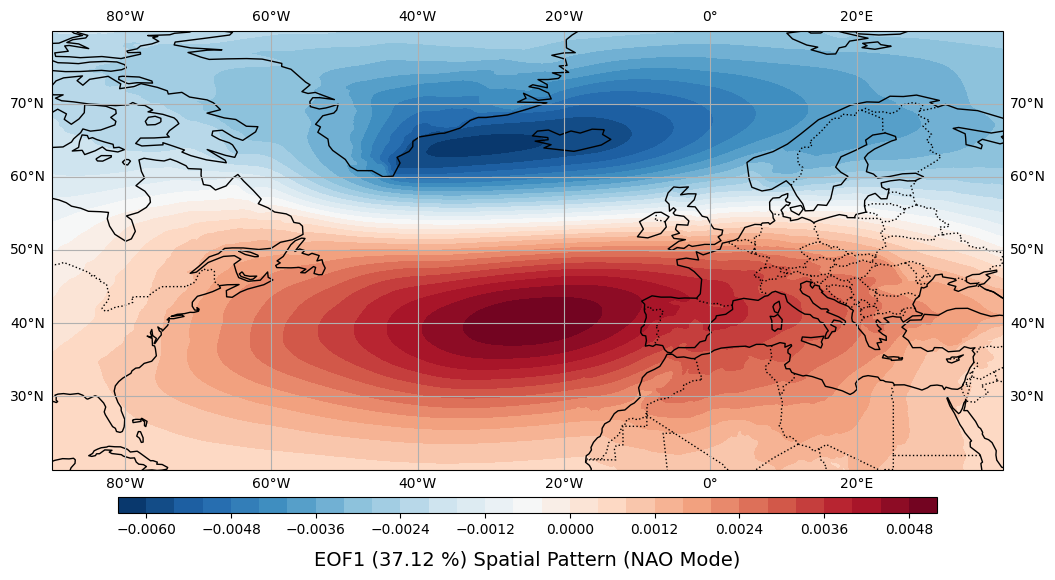

In [ ]:
lon= eof_map['longitude'].values
lat= eof_map['latitude'].values
lon2d, lat2d= np.meshgrid(lon,lat)
data= eof_map.values
#data= np.ma.masked_where(lat2d<20, data)

fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection= ccrs.PlateCarree())

vmax = np.max(np.abs(data))
#levels = np.linspace(-vmax, vmax)  # 21 evenly spaced levels centered at 0

contourf= ax.contourf(
    lon2d, 
    lat2d, 
    data,
    transform= ccrs.PlateCarree(),
    levels=30,
    cmap= 'RdBu_r',
    
)

# Coastlines, borders, gridlines
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

# Colorbar
cb = plt.colorbar(contourf, orientation="horizontal", pad=0.05, aspect=50, shrink=0.7)
cb.set_label('EOF1 (37.12 %) Spatial Pattern (NAO Mode)', labelpad= 10, fontsize=14)
#cb.set_label("Normalized units", fontsize=12)

#ax.set_title('EOF1 (37.12 %) Spatial Pattern (NAO Mode)')
#fig.suptitle('EOF1 (37.12 %) Spatial Pattern (NAO Mode)', y=0.05, fontsize=12)

plt.tight_layout()
#plt.savefig(r'C:\Users\danis\Desktop\Danish\Py-Plots\02_EOF Analysis\NAO_EOF1_Plot.png', dpi=800, bbox_inches='tight')
plt.show()

#### PCA for MJJAS

In [10]:
slp = ds_subset["msl"]
slp_mjjas = slp.isel(time=ablation_index[0])

In [11]:
monthly_climatology= slp_mjjas.groupby('time.month').mean('time')
monthly_anom= slp_mjjas.groupby('time.month') - monthly_climatology

In [12]:
#area weigthing for converging meridians (Baldwin et. al 2007 & NCAR EOF and Rotated EOF Guide)
# extracting lat again from climatology data subset ^

lat_nao_mjjas = monthly_anom.latitude
weights = np.sqrt(np.cos(np.deg2rad(lat_nao_mjjas)))
weighted_anom = monthly_anom * weights
#weighted_anom = weighted_anom.compute()

print(weighted_anom.shape)  # Should print (ntime, nlat, nlon)

# Reshape the data for PCA into 1D array (time, nlat * nlon)
slp = weighted_anom.stack(space=['latitude', 'longitude'])
slp_clean= slp.transpose('time', 'space').values 

(375, 241, 521)


In [13]:
# PCA 
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
slp_pca = pca.fit_transform(slp_clean)

In [14]:
PC1_mjjas = slp_pca[:, 0]
PC2_mjjas = slp_pca[:, 1]

PC1_mjjas_std = (PC1_mjjas - PC1_mjjas.mean()) / PC1_mjjas.std()
PC2_mjjas_std = (PC2_mjjas - PC2_mjjas.mean()) / PC2_mjjas.std()

In [21]:
explained_var_percent = pca.explained_variance_ratio_ * 100
print("Explained Variance (%):", explained_var_percent)

Explained Variance (%): [27.5245907 13.973187 ]


In [22]:
EOF1= pca.components_[0] # shape is (n_gridpoints, )
EOF1= -EOF1
eof_map= xr.DataArray(EOF1, dims= ['space']).assign_coords(space= slp['space']).unstack()

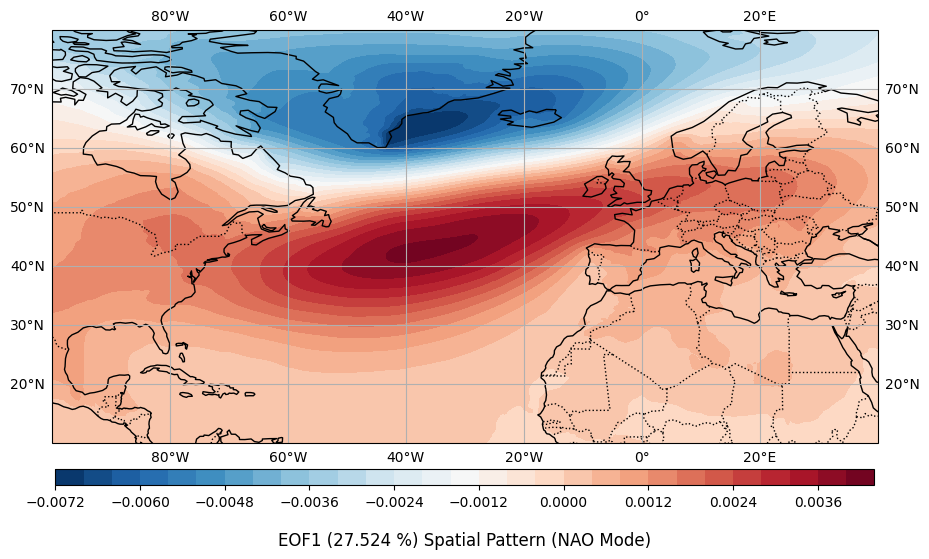

In [24]:
lon= eof_map['longitude'].values
lat= eof_map['latitude'].values
lon2d, lat2d= np.meshgrid(lon,lat)
data= eof_map.values
#data= np.ma.masked_where(lat2d<20, data)

fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection= ccrs.PlateCarree())

vmax = np.max(np.abs(data))
#levels = np.linspace(-vmax, vmax)  # 21 evenly spaced levels centered at 0

contourf= ax.contourf(
    lon2d, 
    lat2d, 
    data,
    transform= ccrs.PlateCarree(),
    levels=30,
    cmap= 'RdBu_r',
    
)

# Coastlines, borders, gridlines
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

# Colorbar
cb = plt.colorbar(contourf, orientation="horizontal", pad=0.05, aspect=50, shrink=0.7)
#cb.set_label("Normalized units", fontsize=12)

#ax.set_title('EOF1 (27.524 %) Spatial Pattern (NAO Mode)')
fig.suptitle('EOF1 (27.524 %) Spatial Pattern (NAO Mode)', y=0.05, fontsize=12)

plt.tight_layout()
#plt.savefig('NAO_EOF1_Plot.png', dpi=800, bbox_inches='tight')
plt.show()

### Constructing AO Index 

In [16]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.linalg import svd
import dask
from sklearn.preprocessing import StandardScaler

In [17]:
file_path = r"C:\Users\danis\Desktop\Danish\ERA5 Data\msl.nc"
ds = xr.open_dataset(file_path, chunks = {"time": 50})
print(ds)

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 902, latitude: 721, longitude: 1440)
Coordinates:
    number     int64 8B ...
  * time       (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2025-02-01
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver     (time) <U4 14kB dask.array<chunksize=(50,), meta=np.ndarray>
Data variables:
    msl        (time, latitude, longitude) float32 4GB dask.array<chunksize=(50, 103, 206), meta=np.ndarray>


C:\Users\danis\AppData\Local\Temp\ipykernel_47872\49479421.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(file_path, chunks = {"time": 50})


In [18]:
lat = ds.latitude.values
lon = ds.longitude.values

#lon_new = np.where(lon > 180, lon - 360, lon)
lat_ao = np.where((lat >= 20) & (lat <= 90))
                   
#ds = ds.assign_coords(longitude= lon_new)
#ds = ds.sortby('longitude')

ds_ao_subset = ds.sel(latitude= slice(90, 20))

In [19]:
slp_ao = ds_ao_subset['msl']

In [20]:
monthly_climatology= slp_ao.groupby('time.month').mean('time')
monthly_anom= slp_ao.groupby('time.month') - monthly_climatology

In [21]:
lat_ao= monthly_anom.latitude
weights = np.sqrt(np.cos(np.deg2rad(monthly_anom.latitude)))
weighted_anom = monthly_anom * weights

print(weighted_anom.shape)

slp = weighted_anom.stack(space=['latitude', 'longitude'])
slp_clean= slp.transpose('time', 'space').values 

(902, 281, 1440)


In [22]:
from sklearn.decomposition import PCA
pca= PCA(n_components= 1)
slp_pca = pca.fit_transform(slp_clean)

ao_index= slp_pca[:, 0]
ao_std = (ao_index - ao_index.mean()) / ao_index.std()

In [23]:
explained_var_percent = pca.explained_variance_ratio_ * 100
print("Explained Variance (%):", explained_var_percent)

Explained Variance (%): [19.56388481]


In [24]:
EOF1_AO= pca.components_[0] # shape is (n_gridpoints, )
EOF1_AO= -EOF1_AO
EOF_AO = EOF1_AO * 1000
eof_map= xr.DataArray(EOF1_AO, dims= ['space']).assign_coords(space= slp['space']).unstack()

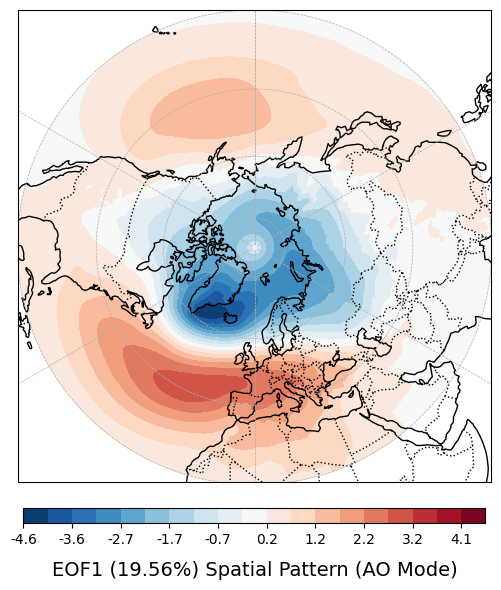

In [26]:
lon= eof_map['longitude'].values
lat= eof_map['latitude'].values
lon2d, lat2d= np.meshgrid(lon,lat)
data= eof_map.values
#data= np.ma.masked_where(lat2d<20, data)
data_scaled = data * 1000

plt.figure(figsize=(12,6))
ax= plt.axes(projection= ccrs.NorthPolarStereo())

vmax = np.max(np.abs(data_scaled))
levels = np.linspace(-vmax, vmax, 20)  # 12 evenly spaced levels centered at 0

contourf= ax.contourf(
    lon2d, 
    lat2d,
    data_scaled,
    transform= ccrs.PlateCarree(),
    levels=levels,
    cmap= 'RdBu_r',
    
)

# Coastlines, borders, gridlines
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=False, linewidth= 0.5, linestyle='--')

# Colorbar
cb = plt.colorbar(contourf, orientation="horizontal", pad=0.05, aspect=30,  fraction =0.03)
cb.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
cb.set_label('EOF1 (19.56%) Spatial Pattern (AO Mode)', labelpad= 10, fontsize=14)

ax.set_extent([-180,180, 20,90], crs= ccrs.PlateCarree())
#ax.set_title('EOF1 (19.56%) Spatial Pattern (AO Mode)')

plt.tight_layout()
#plt.savefig(r'C:\Users\danis\Desktop\Danish\Py-Plots\02_EOF Analysis\AO_EOF1_Plot2.png', dpi=800, bbox_inches='tight')
plt.show()

In [25]:
teleconnection_indices = {
    'NAO_djf_std': PC1_djf_std,
    'EA_djf_std': PC2_djf_std,
    'NAO_mjjas_std': PC1_mjjas_std,
    'EA_mjjas_std': PC2_mjjas_std,
    'AO_std': ao_std
}

import pickle
with open('teleconnection_indices.pkl', 'wb') as f:
    pickle.dump(teleconnection_indices, f)

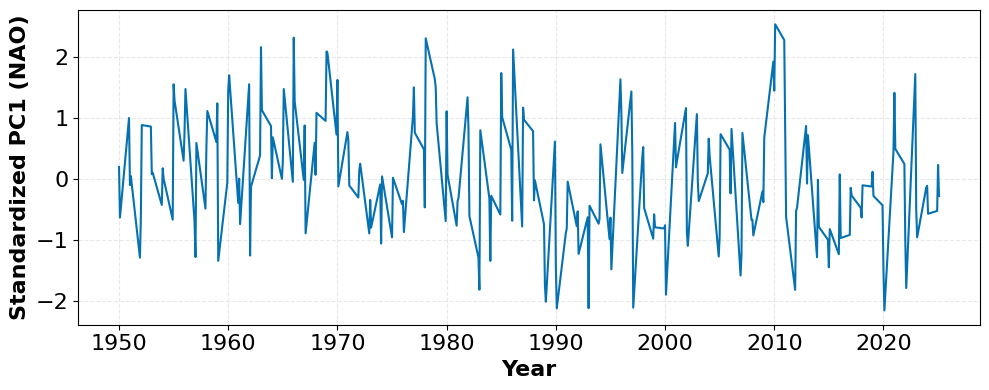

In [26]:
# plotting time series PC1
gridline_color = "#d3d3d3"

plt.figure(figsize=(10, 4))
plt.plot(complete_time[djf_index], PC1_djf_std, color="#0571b0", linewidth=1.5)


plt.xlabel("Year", fontsize=16, fontweight='bold')
plt.ylabel("Standardized PC1 (NAO)", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16) 
plt.yticks(fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5, color=gridline_color)
plt.tight_layout()
#plt.savefig("PC1_MJJAS_TimePlot.png", dpi=800, bbox_inches="tight")
plt.show()


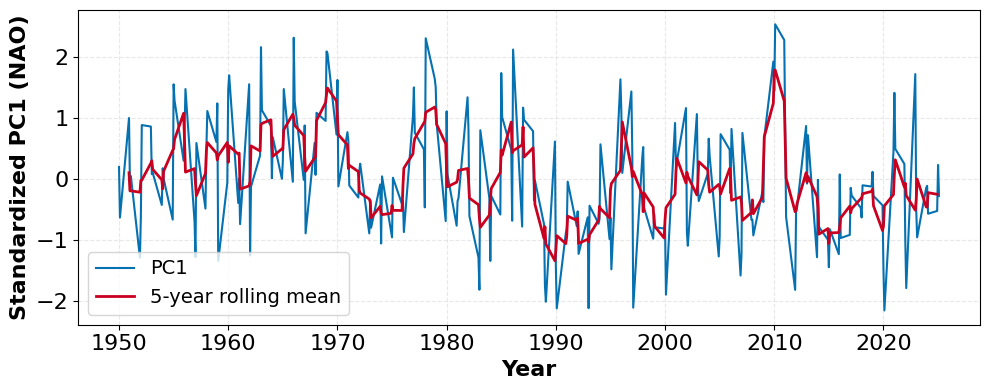

In [ ]:
import pandas as pd
gridline_color = "#d3d3d3"
# Convert PC1 data to a pandas Series
pc1_series = pd.Series(PC1_djf_std)

# Apply rolling mean with a chosen window size (e.g., 5 years)
pc1_rolling = pc1_series.rolling(window=5, center=True).mean()

# Plot both the original data and the rolling mean
plt.figure(figsize=(10, 4))
plt.plot(complete_time[djf_index], PC1_djf_std, color="#0571b0", linewidth=1.5, label="PC1")
plt.plot(complete_time[djf_index], pc1_rolling, color="#ca0020", linewidth=2, label="5-year rolling mean")

plt.xlabel("Year", fontsize=16, fontweight='bold')
plt.ylabel("Standardized PC1 (NAO)", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16) 
plt.yticks(fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5, color=gridline_color)
plt.legend(fontsize=14)
#plt.savefig(r'C:\Users\danis\Desktop\Danish\Py-Plots\10- Discussion Plots\nao_time_series_appendix.png', dpi=800, bbox_inches='tight')

plt.tight_layout()
plt.show()
